# Exploratory Data Analysis on Cafe Sales Data

# **Problem**

#### **We analyze cafe sales data to understand revenue patterns, customer behavior, and product performance.**

## **Define a question :**

1. What is the total revenue generated?
2. Which item generates the highest revenue?
3. Which item has the highest sales volume?
4. Which payment method is used most frequently ?
5. Which service type (takeaway vs in-store) is most used?
6. Which month has the highest total revenue?
7. Which day has the highest total revenue?
8. Which item generates the highest revenue each month?
9. Which item is purchased the most each month?

## Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('dataset/dirty_cafe_sales.csv')

In [3]:
data.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
print('-------------------------------')
print('Jumlah Keseluruhan data adalah ')
print("data :", len(data))
print('-------------------------------')

-------------------------------
Jumlah Keseluruhan data adalah 
data : 10000
-------------------------------


In [5]:
data.head(1)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


There are several data types that we need to change from object to numerical data

In [32]:
data.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


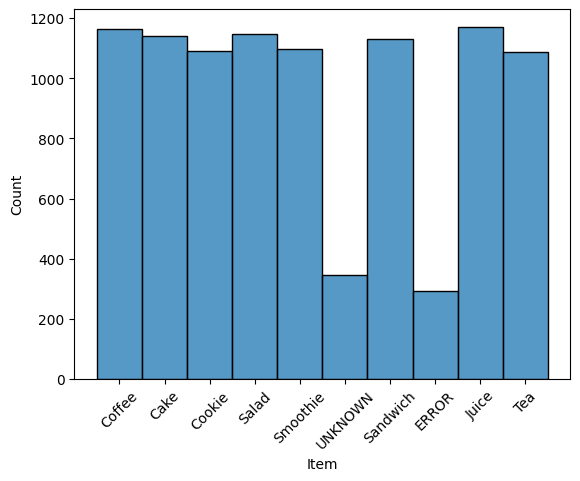

In [33]:
sns.histplot(data=data, x='Item', binwidth=.01)
plt.xticks(rotation=45)
plt.show()

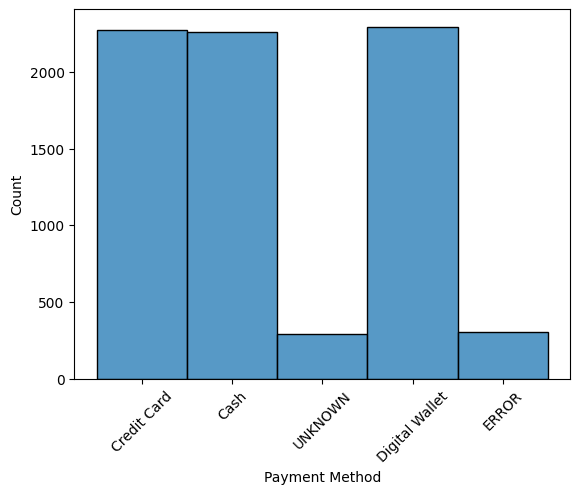

In [34]:
sns.histplot(data=data, x='Payment Method', binwidth=.01)
plt.xticks(rotation=45)
plt.show()

As we can see, there are several values in each column that have "UNKNOWN" and "ERROR" values, besides that, there are also several null values in several columns, so we need to perform data cleaning so that the information produced is much better.

# **Data Cleaning**

#### **1. Handling duplicated values**

In [7]:
data.duplicated().sum() 

0

There is no duplicate values in this data

#### **2. Handling null, unknown, and error values**

In [8]:
data.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [9]:
data.isna().sum().sum()

6826

There are a total of 6826 values that are null data

In [10]:
data[data['Item'].isna()].head(3)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
30,TXN_1736287,NaN,5,2.0,10.0,Digital Wallet,NaN,2023-06-02
61,TXN_8051289,NaN,1,3.0,3.0,NaN,In-store,2023-10-09


After that, we will remove 5% of null values from the total data in each column.

In [11]:
threshold = len(data) * 0.05
print(threshold)

500.0


In [12]:
cols_to_drop = data.columns[data.isna().sum() <= threshold]
print(cols_to_drop)

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Transaction Date'],
      dtype='object')


In [13]:
data.dropna(subset=cols_to_drop, inplace=True)

In [14]:
data.isna().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2322
Location            2959
Transaction Date       0
dtype: int64

In [15]:
len(data)

9059

From the 10,000 data we had at the beginning after dropping null values, 9059 rows of data remain.

#### **3. Handling a noise value in every column**

Because there are values such as "UNKNOWN" and "ERROR" as explained previously, we need to normalize the data from object data type to numerical or from object data type to datetime so that the data can be analyzed properly.

#### Item Column & Price Per Unit Column

In [16]:
print(data.groupby('Price Per Unit')['Item'].unique())

Price Per Unit
1.0                                 [Cookie, UNKNOWN, ERROR]
1.5                                    [ERROR, Tea, UNKNOWN]
2.0                                 [Coffee, ERROR, UNKNOWN]
3.0                            [Cake, UNKNOWN, Juice, ERROR]
4.0                     [Smoothie, Sandwich, UNKNOWN, ERROR]
5.0                                  [Salad, UNKNOWN, ERROR]
ERROR      [Salad, Tea, Cake, Sandwich, Coffee, Juice, Sm...
UNKNOWN    [Cake, Salad, Juice, Cookie, Tea, Smoothie, Co...
Name: Item, dtype: object


To impute missing values in the Item column, the Price Per Unit must first be properly calculated and cleaned. The price is derived by dividing Total Spent by Quantity. Then, a grouping process is performed to identify the most common price for each item. This information is used to fill missing Item values based on the corresponding price.

In [18]:
# Convert this columns to numerical data
cols = ['Price Per Unit', 'Total Spent', 'Quantity']

for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')


mask_price = (
    data['Price Per Unit'].isna() &
    data['Quantity'].notna() &
    data['Total Spent'].notna() &
    (data['Quantity'] != 0)
)


data.loc[mask_price, 'Price Per Unit'] = (
    data.loc[mask_price, 'Total Spent'] / data.loc[mask_price, 'Quantity']
)

In [20]:
data['Price Per Unit'].value_counts()

Price Per Unit
3.0    2339
4.0    2201
2.0    1172
5.0    1163
1.0    1087
1.5    1080
Name: count, dtype: int64

In [21]:
data['Price Per Unit'].isna().sum()

17

Create data mapping by grouping clean data between the Price Per Unit and Item columns.

In [19]:
clean_data = data[
    (~data['Item'].isin(['UNKNOWN', 'ERROR'])) &
    (data['Price Per Unit'].notna())
]

mapping = (
    clean_data
    .groupby('Price Per Unit')['Item']
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)

Fill the item column with the mapping that has been created

In [22]:
mask_item = data['Item'].isin(['UNKNOWN', 'ERROR']) | data['Item'].isna()

data.loc[mask_item, 'Item'] = data.loc[mask_item, 'Price Per Unit'].map(mapping)

In [23]:
data['Item'].isna().sum()

2

In [25]:
data[data['Item'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
3779,TXN_7376255,NaN,NaN,NaN,25.0,NaN,In-store,2023-05-27
4152,TXN_9646000,NaN,2.0,NaN,NaN,NaN,In-store,2023-12-14


There are still missing values, as shown in the previous cell, that cannot be imputed. Therefore, these rows will be removed from the dataset.

In [26]:
data = data.dropna(subset='Item')

In [27]:
data.isna().sum()

Transaction ID         0
Item                   0
Quantity             311
Price Per Unit        15
Total Spent          310
Payment Method      2320
Location            2959
Transaction Date       0
dtype: int64

In [28]:
data.groupby('Price Per Unit')["Item"].unique()

Price Per Unit
1.0                [Cookie]
1.5                   [Tea]
2.0                [Coffee]
3.0           [Cake, Juice]
4.0    [Smoothie, Sandwich]
5.0                 [Salad]
Name: Item, dtype: object

In [29]:
data['Item'].value_counts()

Item
Juice       1274
Sandwich    1182
Coffee      1174
Salad       1164
Cookie      1091
Tea         1083
Cake        1066
Smoothie    1023
Name: count, dtype: int64

In [30]:
data['Price Per Unit'].value_counts()

Price Per Unit
3.0    2339
4.0    2201
2.0    1172
5.0    1163
1.0    1087
1.5    1080
Name: count, dtype: int64

In [32]:
data['Price Per Unit'].isna().sum()

15

After the Item column has been fully cleaned and completed, the missing values in the Price Per Unit column can be imputed using a grouping approach based on the Item column. This process identifies the most common price for each item, which is then used to fill the missing values consistently.

In [33]:
# Convert str to nomeric

# Mapping Item and Price per unit
price_mapping = (
    data
    .groupby('Item')['Price Per Unit']
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)

# Fill nan value
mask = data['Price Per Unit'].isna()

data.loc[mask, 'Price Per Unit'] = data.loc[mask, 'Item'].map(price_mapping)

In [34]:
data['Price Per Unit'].isna().sum()

0

In [36]:
data["Price Per Unit"].value_counts()

Price Per Unit
3.0    2340
4.0    2205
2.0    1174
5.0    1164
1.0    1091
1.5    1083
Name: count, dtype: int64

In [37]:
data["Price Per Unit"].isna().sum().sum()

0

#### Quantity column

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9057 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9057 non-null   object 
 1   Item              9057 non-null   object 
 2   Quantity          8746 non-null   float64
 3   Price Per Unit    9057 non-null   float64
 4   Total Spent       8747 non-null   float64
 5   Payment Method    6737 non-null   object 
 6   Location          6098 non-null   object 
 7   Transaction Date  9057 non-null   object 
dtypes: float64(3), object(5)
memory usage: 636.8+ KB


In [39]:
data['Quantity'].value_counts()

Quantity
5.0    1853
2.0    1811
4.0    1697
1.0    1694
3.0    1691
Name: count, dtype: int64

In [40]:
type(data['Quantity'][0])

numpy.float64

In [42]:
data["Quantity"].isna().sum()

10

To correct inconsistent values in the Quantity column, it is recalculated by dividing Total Spent by Price Per Unit.

In [41]:
mask_qty = (
    data['Quantity'].isna() &
    data['Total Spent'].notna() &
    data['Price Per Unit'].notna() &
    (data['Price Per Unit'] != 0)
)

data.loc[mask_qty, 'Quantity'] = (
    data.loc[mask_qty, 'Total Spent'] / data.loc[mask_qty, 'Price Per Unit']
)

In [43]:
data['Quantity'] = data['Quantity'].round().astype('Int64')

C:\Users\IKHWAN\AppData\Local\Temp\ipykernel_11592\4120812565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Quantity'] = data['Quantity'].round().astype('Int64')


In [44]:
data['Quantity'].isna().sum()

10

In [45]:
data[data['Quantity'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
236,TXN_8562645,Salad,<NA>,5.0,NaN,NaN,In-store,2023-05-18
278,TXN_3229409,Juice,<NA>,3.0,NaN,Cash,Takeaway,2023-04-15
641,TXN_2962976,Juice,<NA>,3.0,NaN,NaN,NaN,2023-03-17
2796,TXN_9188692,Cake,<NA>,3.0,NaN,Credit Card,NaN,2023-12-01
4257,TXN_6470865,Coffee,<NA>,2.0,NaN,Digital Wallet,Takeaway,2023-09-18
5841,TXN_5884081,Cookie,<NA>,1.0,NaN,Digital Wallet,In-store,2023-07-05
7297,TXN_9944500,Smoothie,<NA>,4.0,NaN,Cash,In-store,2023-01-03
8021,TXN_2428781,Salad,<NA>,5.0,NaN,NaN,In-store,2023-05-09
8465,TXN_9669616,Coffee,<NA>,2.0,NaN,NaN,ERROR,2023-06-03
8574,TXN_2546684,Juice,<NA>,3.0,NaN,Digital Wallet,Takeaway,2023-04-08


In [46]:
len(data)

9057

Rows with missing Total Spent and Quantity values are removed, as they cannot be reliably imputed and represent only a negligible portion of the dataset (10 out of 9000 rows).

In [47]:
data = data.dropna(subset=["Quantity", "Total Spent"], how='all')

In [48]:
data["Quantity"].isna().sum()

0

#### Total Spent Column

In [49]:
data["Total Spent"].value_counts()

Total Spent
6.0     909
3.0     858
4.0     857
12.0    854
20.0    684
15.0    674
8.0     622
10.0    483
2.0     456
9.0     443
5.0     427
16.0    405
25.0    244
7.5     222
1.0     212
4.5     205
1.5     192
Name: count, dtype: int64

In [50]:
data["Total Spent"].isna().sum()

300

The Total Spent value is calculated by multiplying Quantity by Price Per Unit.

In [51]:
data["Total Spent"] = data["Total Spent"].fillna(data['Quantity'] * data['Price Per Unit'])

In [52]:
data["Total Spent"].isna().sum()

0

In [53]:
data.isna().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2316
Location            2957
Transaction Date       0
dtype: int64

### Payment Method Column

In [54]:
data["Payment Method"].value_counts()

Payment Method
Digital Wallet    2082
Credit Card       2047
Cash              2047
ERROR              289
UNKNOWN            266
Name: count, dtype: int64

In [55]:
dist = (
    data.loc[~data['Payment Method'].isin(['ERROR', 'UNKNOWN']), 'Payment Method']
    .value_counts(normalize=True)
)

# Change ERROR & UNKNOWN values to NaN
data['Payment Method'] = data['Payment Method'].replace(['ERROR', 'UNKNOWN'], np.nan)

# Mask missing
mask = data['Payment Method'].isna()

# Fill based on distribution
data.loc[mask, 'Payment Method'] = np.random.choice(
    dist.index,
    size=mask.sum(),
    p=dist.values
)

Missing values in the Payment Method column are imputed using a distribution-based approach. Since the distribution among categories (Digital Wallet, Credit Card, and Cash) is relatively balanced, this method helps preserve the original data distribution and minimizes bias.

In [56]:
data["Payment Method"].value_counts()

Payment Method
Cash              3019
Digital Wallet    3016
Credit Card       3012
Name: count, dtype: int64

In [57]:
data["Payment Method"].isna().sum()

0

In [58]:
data.isna().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method         0
Location            2957
Transaction Date       0
dtype: int64

### Location Column

In [59]:
data['Location'].value_counts()

Location
Takeaway    2737
In-store    2722
ERROR        326
UNKNOWN      305
Name: count, dtype: int64

In [60]:
dist = (
    data.loc[~data['Location'].isin(['ERROR', 'UNKNOWN']), 'Location']
    .value_counts(normalize=True)
)

# Change ERROR & UNKNOWN values to NaN
data['Location'] = data['Location'].replace(['ERROR', 'UNKNOWN'], np.nan)

# Mask missing
mask = data['Location'].isna()

# Fill based on distribution
data.loc[mask, 'Location'] = np.random.choice(
    dist.index,
    size=mask.sum(),
    p=dist.values
)

Same with Payment Method column, Location column are imputed using a distribution-based approach. Since the distribution among categories is relatively balanced, this method helps preserve the original data distribution and minimizes bias.

In [62]:
data['Location'].value_counts()

Location
Takeaway    4564
In-store    4483
Name: count, dtype: int64

In [63]:
data['Location'].isna().sum()

0

In [66]:
data.isna().sum() # There is no null value left

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

#### Transaction Date Column

In [64]:
print("------------------------------------------------------------------------------------------------------")
print("Length of data", len(data))
print("Length of UNKNOWN values in Transaction Date column :", len(data[data['Transaction Date'] == 'UNKNOWN']))
print("Length of ERROR values in Transaction Date column :", len(data[data['Transaction Date'] == 'ERROR']))
print("------------------------------------------------------------------------------------------------------")

------------------------------------------------------------------------------------------------------
Length of data 9047
Length of UNKNOWN values in Transaction Date column : 143
Length of ERROR values in Transaction Date column : 128
------------------------------------------------------------------------------------------------------


In [67]:
print(len(data) - (len(data[data['Transaction Date'] == 'UNKNOWN']) + len(data[data['Transaction Date'] == 'ERROR']))) 

8776


In [68]:
data = data[~data["Transaction Date"].isin(['UNKNOWN', 'ERROR'])]

In [69]:
data['Transaction Date'].value_counts()

Transaction Date
2023-07-24    38
2023-03-13    37
2023-01-25    36
2023-07-21    36
2023-06-16    36
              ..
2023-04-22    13
2023-02-17    13
2023-03-11    13
2023-04-27    13
2023-11-24    12
Name: count, Length: 365, dtype: int64

### **Data Validation**

Next, we perform data validation to ensure that each column has the correct data type.

In [70]:
data.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [71]:
data.head(1)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08


In [72]:
type(data['Transaction ID'][0])

str

In [73]:
type(data['Item'][0])

str

In [74]:
type(data['Quantity'][0])

numpy.int64

In [75]:
type(data['Price Per Unit'][0])

numpy.float64

In [76]:
type(data['Total Spent'][0])

numpy.float64

In [77]:
type(data['Payment Method'][0])

str

In [78]:
type(data['Location'][0])

str

In [79]:
type(data['Transaction Date'][0])

str

We need to transform Transaction Date data type to datetime

In [80]:
data['Transaction Date'] = pd.to_datetime(data['Transaction Date'])

In [83]:
type(data['Transaction Date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [84]:
data.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Cash,In-store,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8776 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    8776 non-null   object        
 1   Item              8776 non-null   object        
 2   Quantity          8776 non-null   Int64         
 3   Price Per Unit    8776 non-null   float64       
 4   Total Spent       8776 non-null   float64       
 5   Payment Method    8776 non-null   object        
 6   Location          8776 non-null   object        
 7   Transaction Date  8776 non-null   datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), float64(2), object(4)
memory usage: 883.7+ KB


#### **Create Day, Month, and Year column**

Next, we create new columns for year, month, and day to facilitate further analysis.

In [90]:
data['Day'] = data['Transaction Date'].dt.day_name()

In [91]:
data['Month'] = data['Transaction Date'].dt.month_name()

In [92]:
data['Year'] = data['Transaction Date'].dt.year

In [93]:
data.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day,Month,Year
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday,September,2023
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,Tuesday,May,2023
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,Wednesday,July,2023
3,TXN_7034554,Salad,2,5.0,10.0,Cash,In-store,2023-04-27,Thursday,April,2023
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,Sunday,June,2023


### **Saving cleaned data**

After completing the data cleaning process, the dataset is saved, and the analysis phase is conducted.

In [94]:
data.to_csv('dataset/cafe_sales_cleaned.csv', index=False)

## **Analysis**

#### 1. What is the total revenue generated?

In [96]:
total_revenue = data['Total Spent'].sum()

In [97]:
print("Total revenue in this dataset that is 2023 cafe sales is", total_revenue)

Total revenue in this dataset that is 2023 cafe sales is 78338.5


#### 2. Which item generates the highest revenue?

In [109]:
item_revenue = data.groupby('Item')['Total Spent'].sum()
item_highest_revenue = item_revenue.idxmax()

In [110]:
print("Item with the highest revenue is :", item_highest_revenue)

'Salad'

In [121]:
item_revenue

,Item,Total Spent
4,Salad,17025.0
5,Sandwich,13900.0
6,Smoothie,12224.0
3,Juice,11043.0
0,Cake,9297.0
1,Coffee,6946.0
7,Tea,4759.5
2,Cookie,3144.0


C:\Users\IKHWAN\AppData\Local\Temp\ipykernel_11592\918257201.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=item_revenue, x='Item', y='Total Spent', palette='coolwarm')


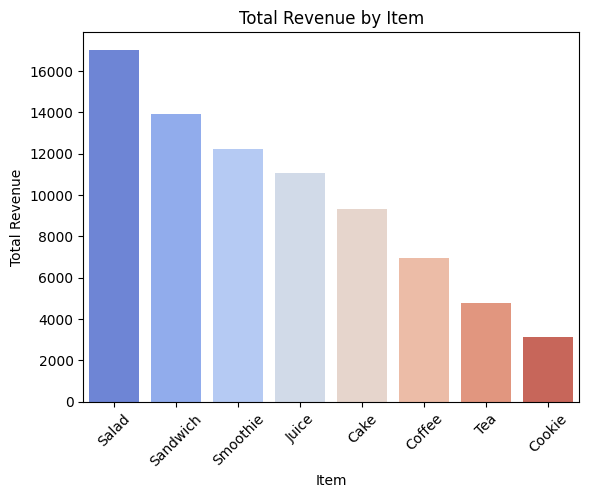

In [123]:
item_revenue = (data.groupby('Item')['Total Spent'].sum().reset_index().sort_values(by='Total Spent',ascending=False))

plt.figure()
sns.barplot(data=item_revenue, x='Item', y='Total Spent', palette='coolwarm')
plt.title("Total Revenue by Item")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.da
plt.show()

#### 3. Which item has the highest sales volume?

In [124]:
item_quantity = data.groupby('Item')['Quantity'].sum()
highest_item_quantity = item_quantity.idxmax()

In [126]:
print("Item with the highest sales volume is :", highest_item_quantity)

Item with the highest sales volume is : Juice


In [127]:
item_quantity

Item
Cake        3099
Coffee      3473
Cookie      3144
Juice       3681
Salad       3405
Sandwich    3475
Smoothie    3056
Tea         3173
Name: Quantity, dtype: Int64

C:\Users\IKHWAN\AppData\Local\Temp\ipykernel_11592\2406791865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=item_quantity, x='Item', y='Quantity', palette='magma')


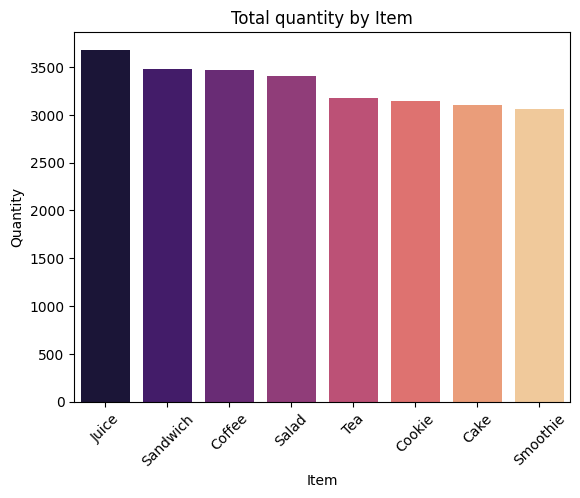

In [130]:
item_quantity = item_quantity.reset_index().sort_values(by='Quantity', ascending=False)

sns.barplot(data=item_quantity, x='Item', y='Quantity', palette='magma')
plt.title('Total quantity by Item')
plt.xticks(rotation=45)
plt.show()

#### 4. Which payment method is used most frequently ?

In [133]:
payment_method_frequently = data.groupby('Payment Method')['Transaction ID'].count()

In [135]:
payment_method_frequently.sort_values(ascending=False)

Payment Method
Cash              2933
Digital Wallet    2924
Credit Card       2919
Name: Transaction ID, dtype: int64

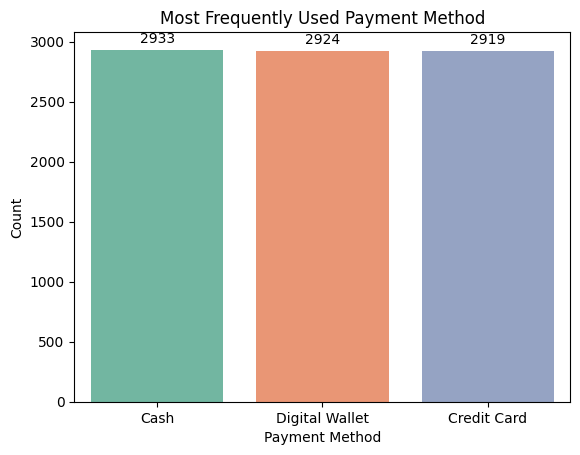

In [147]:
count_data = data['Payment Method'].value_counts().reset_index()
count_data.columns = ['Payment Method', 'Count']

plt.figure()
ax = sns.barplot(
    data=count_data,
    x='Payment Method',
    y='Count',
    hue='Payment Method',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Most Frequently Used Payment Method')
plt.show()

#### 5. Which service type (takeaway vs in-store) is most used?

In [148]:
service_type_frequently = data.groupby('Location')['Transaction ID'].count()

In [149]:
service_type_frequently.sort_values(ascending=False)

Location
Takeaway    4420
In-store    4356
Name: Transaction ID, dtype: int64

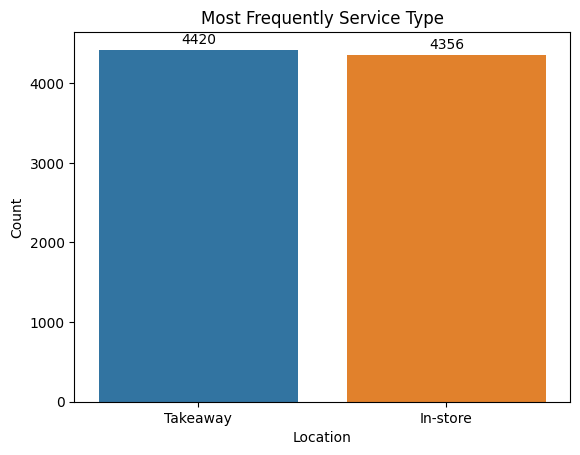

In [159]:
count_data = data['Location'].value_counts().reset_index()
count_data.columns = ['Location', 'Count']

plt.figure()
ax = sns.barplot(
    data=count_data,
    x='Location',
    y='Count',
    hue='Location',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.title('Most Frequently Service Type')
plt.show()

#### 6. Which month has the highest total revenue?

In [160]:
month_revenue = data.groupby('Month')['Total Spent'].sum()
month_highest_revenue = month_revenue.idxmax()

In [161]:
month_highest_revenue

'January'

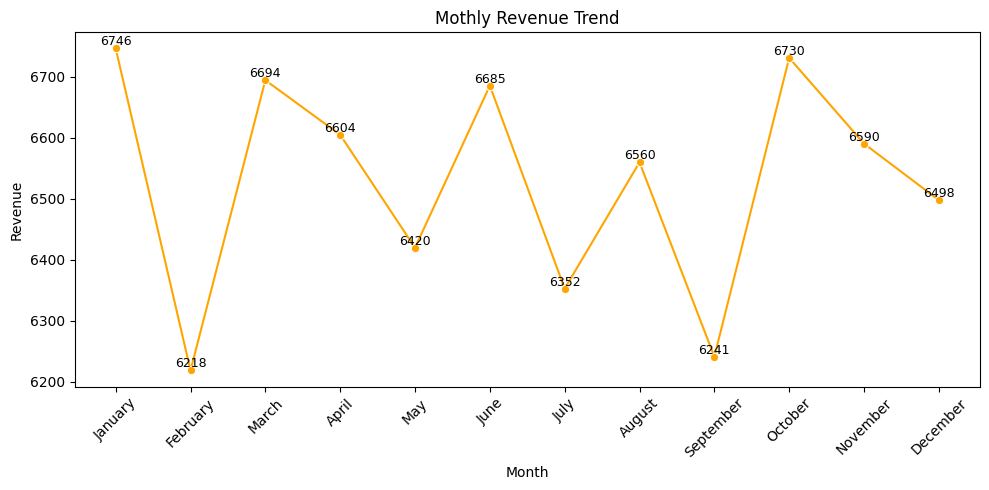

In [185]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']


month_revenue = (
    data.groupby('Month')['Total Spent']
    .sum()
    .reset_index()
                )

month_revenue['Month'] = pd.Categorical(
    month_revenue['Month'],
    categories=month_order,
    ordered=True
)

month_revenue = month_revenue.sort_values('Month')

plt.figure(figsize=(10,5))

ax = sns.lineplot(data=month_revenue, 
             x='Month', 
             y='Total Spent', 
             color='orange',
             marker='o')

for i, y in enumerate(month_revenue['Total Spent']):
    ax.text(i, y, f'{y:.0f}', ha='center', va='bottom', fontsize=9)

plt.title('Mothly Revenue Trend')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### 7. Which day has the highest total revenue?

In [186]:
day_revenue = data.groupby('Day')['Total Spent'].sum()
day_highest_revenue = day_revenue.idxmax()

In [187]:
day_highest_revenue

'Thursday'

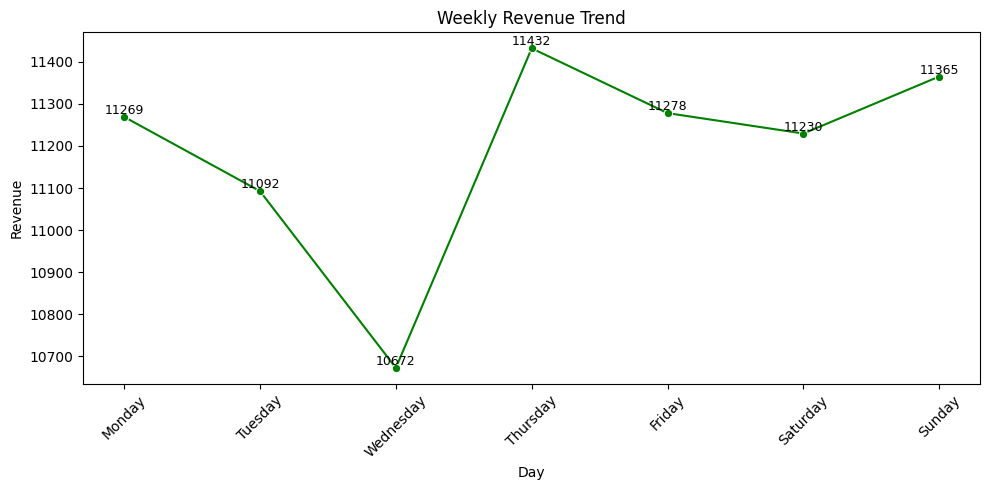

In [201]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_revenue = (
    data.groupby(['Day'])['Total Spent']
    .sum()
    .reset_index()
                )

day_revenue['Day'] = pd.Categorical(
    day_revenue['Day'],
    categories=day_order,
    ordered=True
)

day_revenue = day_revenue.sort_values('Day')

plt.figure(figsize=(10,5))

ax = sns.lineplot(data=day_revenue,
             x='Day', 
             y='Total Spent', 
             color='green',
             marker='o')

for i, y in enumerate(day_revenue['Total Spent']):
    ax.text(i, y, f'{y:.0f}', ha='center', va='bottom', fontsize=9)

plt.title('Weekly Revenue Trend')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

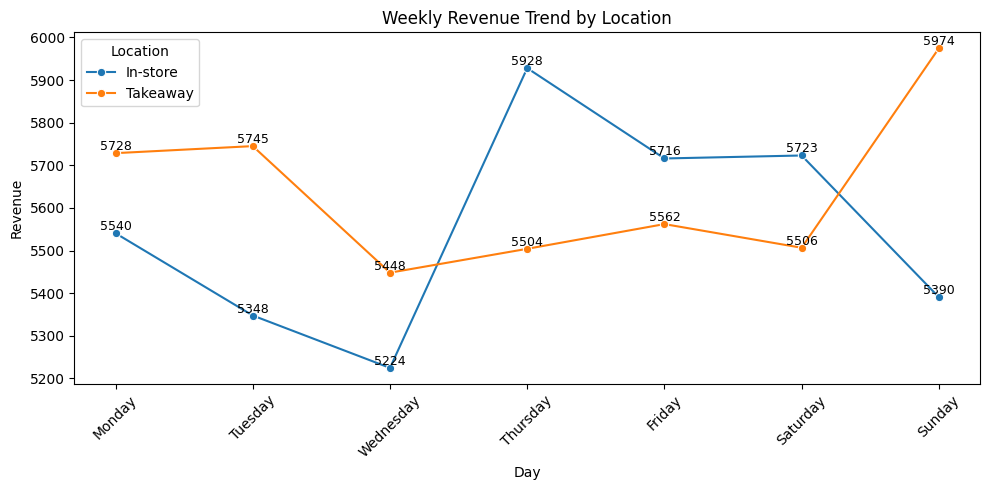

In [262]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_revenue = (
    data.groupby(['Day', 'Location'])['Total Spent']
    .sum()
    .reset_index()
                )

day_revenue['Day'] = pd.Categorical(
    day_revenue['Day'],
    categories=day_order,
    ordered=True
)

day_revenue = day_revenue.sort_values('Day')

plt.figure(figsize=(10,5))

ax = sns.lineplot(data=day_revenue,
             x='Day', 
             y='Total Spent', 
             hue='Location',
             color='green',
             marker='o')

# Label per garis (benar)
for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    
    for x, y in zip(x_data, y_data):
        ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=9)
    

plt.title('Weekly Revenue Trend by Location')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### 8. Which item generates the highest revenue each month?

In [233]:
month_item = data.pivot_table(index='Item', columns='Month', values='Total Spent', aggfunc='sum')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']
month_item = month_item[month_order]
month_highest_item = month_item.idxmax()

In [234]:
month_item

Month,January,February,March,April,May,June,July,August,September,October,November,December
Item,,,,,,,,,,,,
Cake,831.0,657.0,726.0,750.0,819.0,717.0,672.0,819.0,819.0,879.0,876.0,732.0
Coffee,564.0,586.0,622.0,530.0,552.0,598.0,580.0,610.0,496.0,690.0,506.0,612.0
Cookie,249.0,222.0,288.0,228.0,251.0,258.0,306.0,254.0,293.0,257.0,281.0,257.0
Juice,1014.0,912.0,1008.0,996.0,927.0,954.0,690.0,852.0,816.0,978.0,909.0,987.0
Salad,1545.0,1300.0,1505.0,1500.0,1290.0,1480.0,1590.0,1445.0,1150.0,1465.0,1470.0,1285.0
Sandwich,1424.0,1184.0,1208.0,1088.0,1236.0,1160.0,1112.0,1132.0,1164.0,952.0,1080.0,1160.0
Smoothie,720.0,960.0,944.0,1136.0,992.0,1128.0,996.0,1020.0,1068.0,1052.0,1120.0,1088.0
Tea,399.0,397.5,393.0,376.5,352.5,390.0,406.5,427.5,435.0,457.5,348.0,376.5


In [235]:
month_highest_item

Month
January         Salad
February        Salad
March           Salad
April           Salad
May             Salad
June            Salad
July            Salad
August          Salad
September    Sandwich
October         Salad
November        Salad
December        Salad
dtype: object

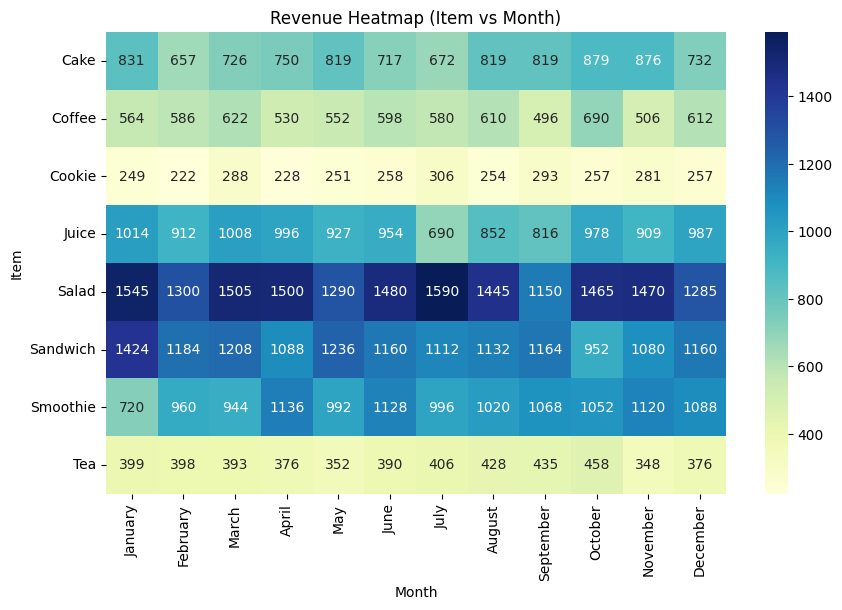

In [236]:
plt.figure(figsize=(10,6))

sns.heatmap(month_item, annot=True, fmt='.0f', cmap='YlGnBu')

plt.title('Revenue Heatmap (Item vs Month)')
plt.show()

#### 9. Which item is purchased the most each month?

In [256]:
data['Quantity'] = data['Quantity'].astype(int)

In [257]:
month_quantity_item = data.pivot_table(index='Item', columns='Month', values='Quantity', aggfunc='sum')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_quantity_item = month_quantity_item[month_order]
month_highest_item_quantity = month_quantity_item.idxmax()

In [258]:
month_quantity_item

Month,January,February,March,April,May,June,July,August,September,October,November,December
Item,,,,,,,,,,,,
Cake,277,219,242,250,273,239,224,273,273,293,292,244
Coffee,282,293,311,265,276,299,290,305,248,345,253,306
Cookie,249,222,288,228,251,258,306,254,293,257,281,257
Juice,338,304,336,332,309,318,230,284,272,326,303,329
Salad,309,260,301,300,258,296,318,289,230,293,294,257
Sandwich,356,296,302,272,309,290,278,283,291,238,270,290
Smoothie,180,240,236,284,248,282,249,255,267,263,280,272
Tea,266,265,262,251,235,260,271,285,290,305,232,251


In [259]:
print(month_quantity_item.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, Cake to Tea
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   January    8 non-null      int32
 1   February   8 non-null      int32
 2   March      8 non-null      int32
 3   April      8 non-null      int32
 4   May        8 non-null      int32
 5   June       8 non-null      int32
 6   July       8 non-null      int32
 7   August     8 non-null      int32
 8   September  8 non-null      int32
 9   October    8 non-null      int32
 10  November   8 non-null      int32
 11  December   8 non-null      int32
dtypes: int32(12)
memory usage: 448.0+ bytes
None


In [260]:
month_highest_item_quantity

Month
January      Sandwich
February        Juice
March           Juice
April           Juice
May             Juice
June            Juice
July            Salad
August         Coffee
September      Cookie
October        Coffee
November        Juice
December        Juice
dtype: object

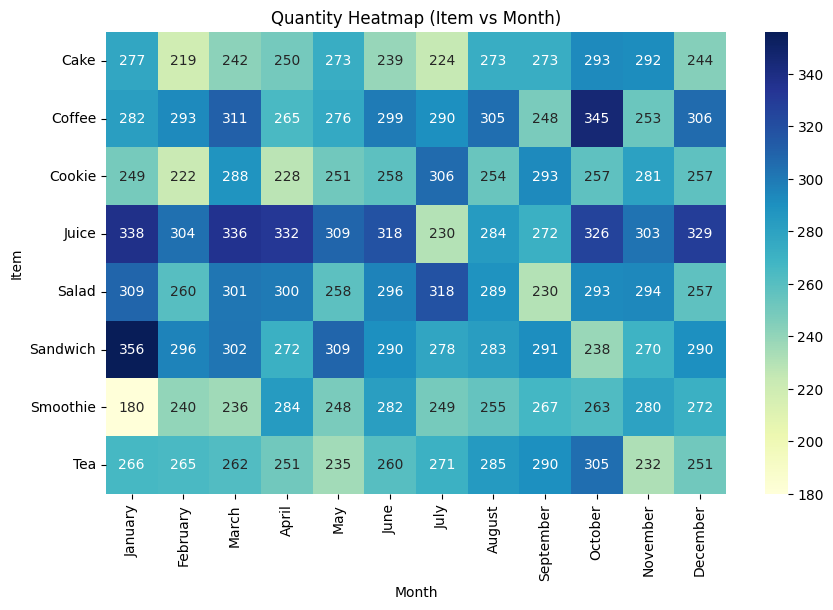

In [261]:
plt.figure(figsize=(10,6))

sns.heatmap(month_quantity_item, annot=True, fmt='.0f', cmap='YlGnBu')

plt.title('Quantity Heatmap (Item vs Month)')
plt.show()